 <font size="10">**Script 06: Data transformation and dimensionality reduction: part 1**</font>
***

<div class="alert alert-info">
    
<b> <h1> ℹ️ <strong> <font size="6" color="black"> Important notebook information </font> </strong> </h1> </b>
    <hr>
    <font size="4" color="black">
        The purpose of this notebook is to transform the data and perform dimensionality reduction in order to represent the embyo data in low dimensional space  and qualatatively look at different sources of metadata to see if any might be contributing as technical batch covariates<br> <br>
    This scipt will transform the data using a function which utalises scanpy preprocessing functions</font>

# Import packages

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import os
import sys
import datetime
import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from kneed import KneeLocator


import warnings
warnings.filterwarnings("ignore")

inline_rc = dict(mpl.rcParams)

#to set unique date for outputs
calc_date = datetime.datetime.now()
date=calc_date.strftime('%Y-%m-%d')
#date=calc_date.strftime('%d-%m-%Y')
date = date.replace('-', '')

cwd = os.getcwd()

sc.settings.verbosity = 2

# Note: package versions can be located in dependencies at the bottom of the script

# User settings interaction block
This notbook is to transform the data ready for futher exploration and provide template to how the data will be transformed in other scripts

In [2]:
### User settings block ###

# Set root directory so all files and outputs can be found within one overarching location
root_directory = '/home/jovyan/mount_farm/nfs/ar32/Whole_embryo/'

# set directory path to Whole_Embryo_utils.py: This python script hold modules / functions which are used within the script 
Whole_Embryo_utils_path = root_directory + "Utlis/"


# set directory path for the combined embryo anndata object from script 05
Comb_path = root_directory + 'Outputs/Objects/Post_QC/Combined_n_3_raw_counts_low_quailty_cells_removed_20220427.h5ad'
data_name = 'Combined_n_3_raw_counts_low_quailty_cells_removed_20220427'


# set directory path to save script outputs:
Objects_out_path = root_directory + 'Outputs/Objects/Post_QC/' # for anndata object
Metadata_out_path = root_directory + 'Outputs/Metadata/06_PP_DM/' # for metadata

umap_seed = 0

#############################################################################################################################


### Running checking directory paths to Whole_Embryo_utils.py and save directory paths ###

sys.path.append(Whole_Embryo_utils_path)
import Whole_Embryo_utils as eu

print('Checking file path for saving anndata objects:', "\n")
eu.save_path(Objects_out_path)
print("")
print('Checking file path for saving metadata:', "\n")
eu.save_path(Metadata_out_path)

Checking file path for saving anndata objects: 

File path provided exists
To save data to this location use the inputed variable at the start of the file path

Checking file path for saving metadata: 

File path provided exists
To save data to this location use the inputed variable at the start of the file path


# Script start

In [3]:
# Load in anndata object
print('\033[1m' + f'Anndata object to load: {data_name}'+ '\033[0m')
adata = eu.load(Comb_path, Method='h5ad')
print('\033[1m' + 'Data loaded under variable: adata'+ '\033[0m')

Anndata object to load: Combined_n_3_raw_counts_low_quailty_cells_removed_20220427
Beginning to load data:
Method chosen for loading is h5ad out of the options: h5ad , h5 or mtx

Data loaded in successfully
Overall shape: (1138964, 36601)
Min count: 0.0
Max count: 16057.0

Data loaded under variable: adata


## Transform counts data

# Technically don't need to scale for dimensionality reduction

In [4]:
eu.transform_data(adata, how='fnlh', batch_key='haniffa_ID')

filtered out 2017 genes that are detected in less than 5 cells
normalizing by total count per cell
    finished (0:01:30): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
extracting highly variable genes
    finished (0:03:25)


Data transformation complete. 
Runtime: 503.4300494194031s

Options performed in order: ['Filtered low quality genes', 'Normalised per cell to 10000', 'Natural Logged', 'Gene feature selection by batch']


In [5]:
sc.pp.pca(adata, n_comps=100, use_highly_variable=True, svd_solver='arpack')

computing PCA
    on highly variable genes
    with n_comps=100
    finished (0:06:37)


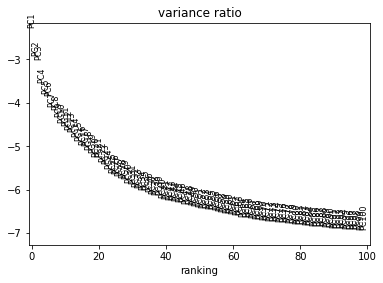

In [6]:
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=100)

Elbow point for Varience explained around: 33 PCs | elbow score for y axis: -6.007825225427804



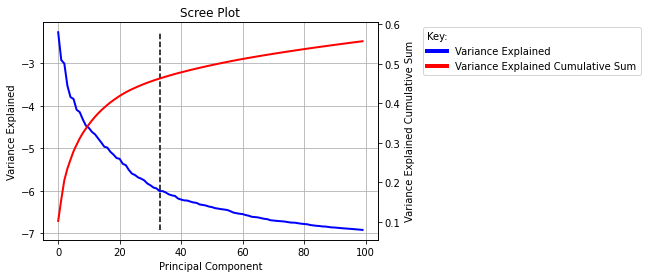

In [7]:
os.chdir(Metadata_out_path)

PC_values = np.arange(len((adata.uns['pca']['variance_ratio'])))
Varience_explained = np.log(adata.uns['pca']['variance_ratio']).T
cumulative_sum = adata.uns['pca']['variance_ratio'].cumsum()

kn = KneeLocator(PC_values, Varience_explained, curve='convex', direction='decreasing')

fig, ax = plt.subplots()
l1 = sns.lineplot(PC_values, Varience_explained, linewidth=2, color='blue', ax=ax)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
ax2 = ax.twinx()
l2 = sns.lineplot(PC_values, cumulative_sum, linewidth=2, color='red', ax=ax2)
plt.ylabel('Variance Explained Cumulative Sum')

plt.vlines(kn.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', color='black')
ax.grid(True)

legend_elements = [Line2D([0], [0], color='blue', lw=4, label='Variance Explained'),
                   Line2D([0], [0], color='red', lw=4, label='Variance Explained Cumulative Sum')]
legend = plt.legend(handles=legend_elements, markerscale=0.5,  bbox_to_anchor=[1.8, 1], loc='upper right',title='Key:')
legend._legend_box.align = "left"

plt.savefig("Scree_Plot.png")
print('\033[1m' + f'Elbow point for Varience explained around: {round(kn.knee, 3)} PCs | elbow score for y axis: {kn.elbow_y}'+ '\033[0m')
print("")

### Plataeu visually seems to be around 75 PCs so going forward with 75 PCs for first round checking

# Check what genes are contributing to the most varience in PC's 

In [8]:
# Look at list of loadings for a selected PC
PCs = [1,2,3,4,5,6,7,8,9,10]

# Get loadings for each gene for each PC
df_loadings = pd.DataFrame(adata.varm['PCs'], index=adata.var_names)
# get rank of each loading for each PC
df_rankings = pd.DataFrame((-1 * df_loadings.values).argsort(0).argsort(0), index=df_loadings.index, columns=df_loadings.columns)

for PC in PCs:
    PC_of_interest = PC
    print("="*60, "\n")
    print(f'Top loadings for PC{PC_of_interest}:')
    print(df_loadings[(PC_of_interest-1)].sort_values(ascending=False).head(20))
    print()
    print("="*60, "\n")
    print()


Top loadings for PC1:
TUBB3     0.207896
STMN2     0.162625
CKB       0.160853
TUBB2B    0.159070
MAP1B     0.131586
TAGLN3    0.110775
CRMP1     0.107371
INA       0.103952
NEFM      0.100282
TUBB2A    0.098910
CD24      0.090906
DCX       0.090494
RTN1      0.088103
MLLT11    0.085372
MAP2      0.083860
NEFL      0.082470
KIF5C     0.078052
GAP43     0.077219
STMN4     0.076093
GDI1      0.073949
Name: 0, dtype: float64




Top loadings for PC2:
HBG1          0.174181
MT2A          0.139298
HBA2          0.139130
HBA1          0.138914
MT1G          0.122302
BLVRB         0.112534
AC104389.5    0.109249
HBM           0.109071
AHSP          0.106824
GYPC          0.103000
MT1E          0.102650
SLC25A37      0.102209
ALAS2         0.095303
MT1H          0.094731
MT1X          0.086896
MT1F          0.084656
RGS10         0.068252
GYPB          0.067214
SLC25A39      0.067155
UCP2          0.065405
Name: 1, dtype: float64




Top loadings for PC3:
HIST1H4C    0.187486
CENPF       0.18

# See how these top loadings affect anatomical sections

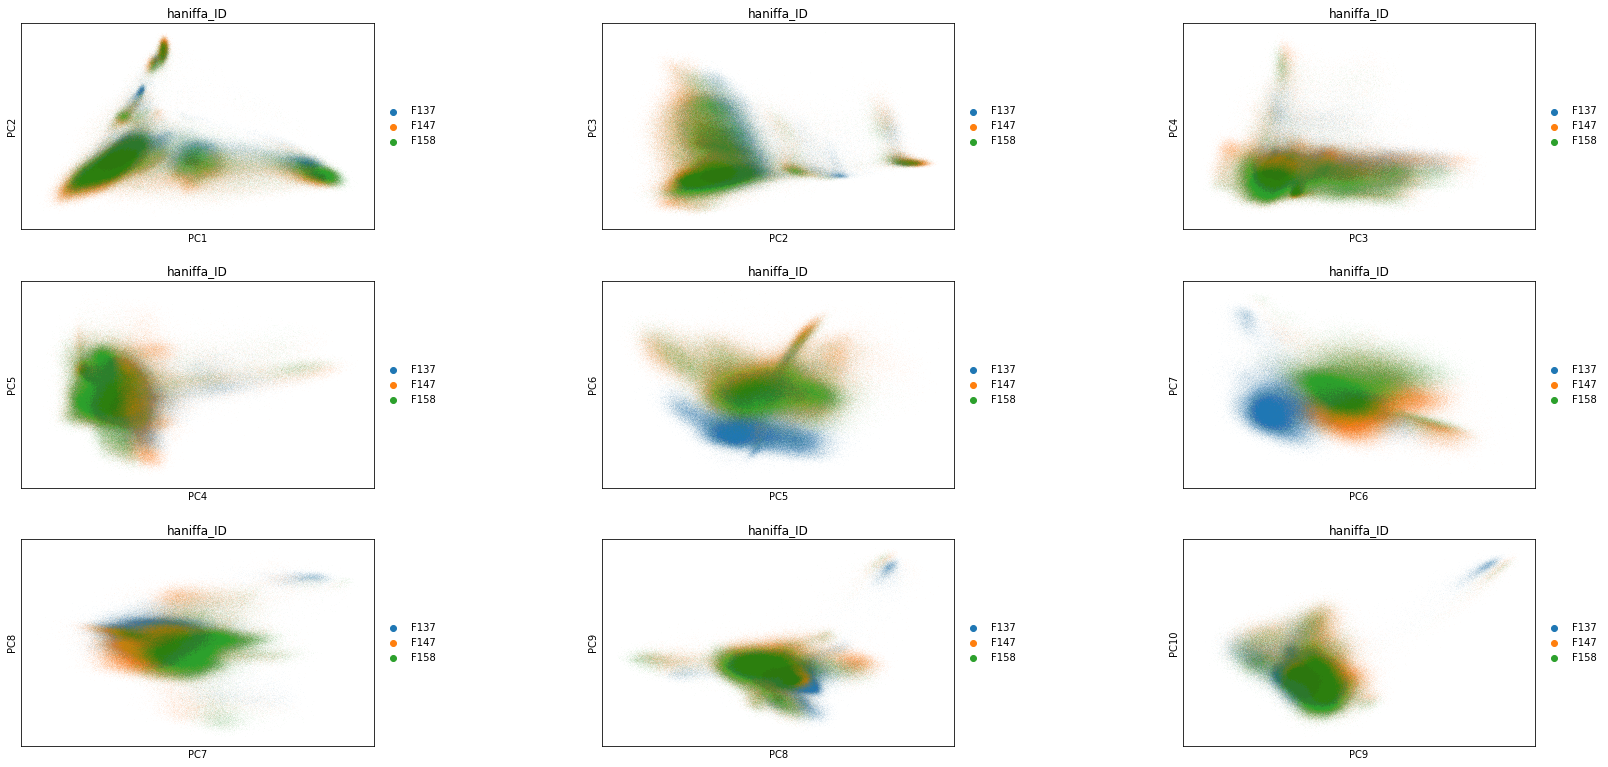

In [9]:
# plot PCs by Embryo section
sc.pl.pca(adata, color='haniffa_ID', components = ['1,2','2,3','3,4','4,5','5,6','6,7','7,8','8,9','9,10'], ncols=3, wspace=0.5, save='Principal_components_colored_by_haniffa_ID.pdf')

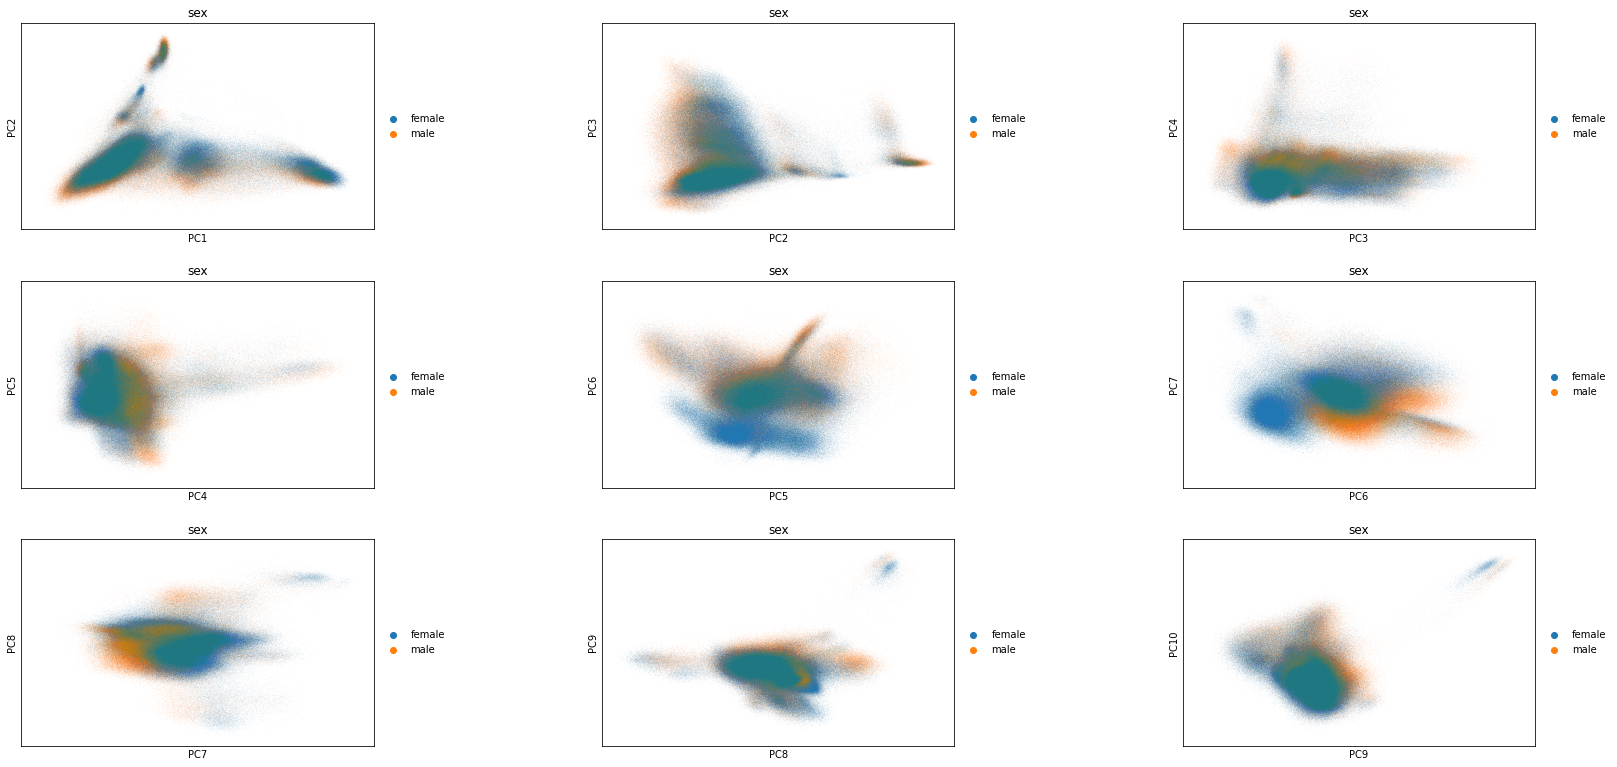

In [10]:
# plot PCs by Embryo section
sc.pl.pca(adata, color='sex', components = ['1,2','2,3','3,4','4,5','5,6','6,7','7,8','8,9','9,10'], ncols=3, wspace=0.5, save='Principal_components_colored_by_sex.pdf')

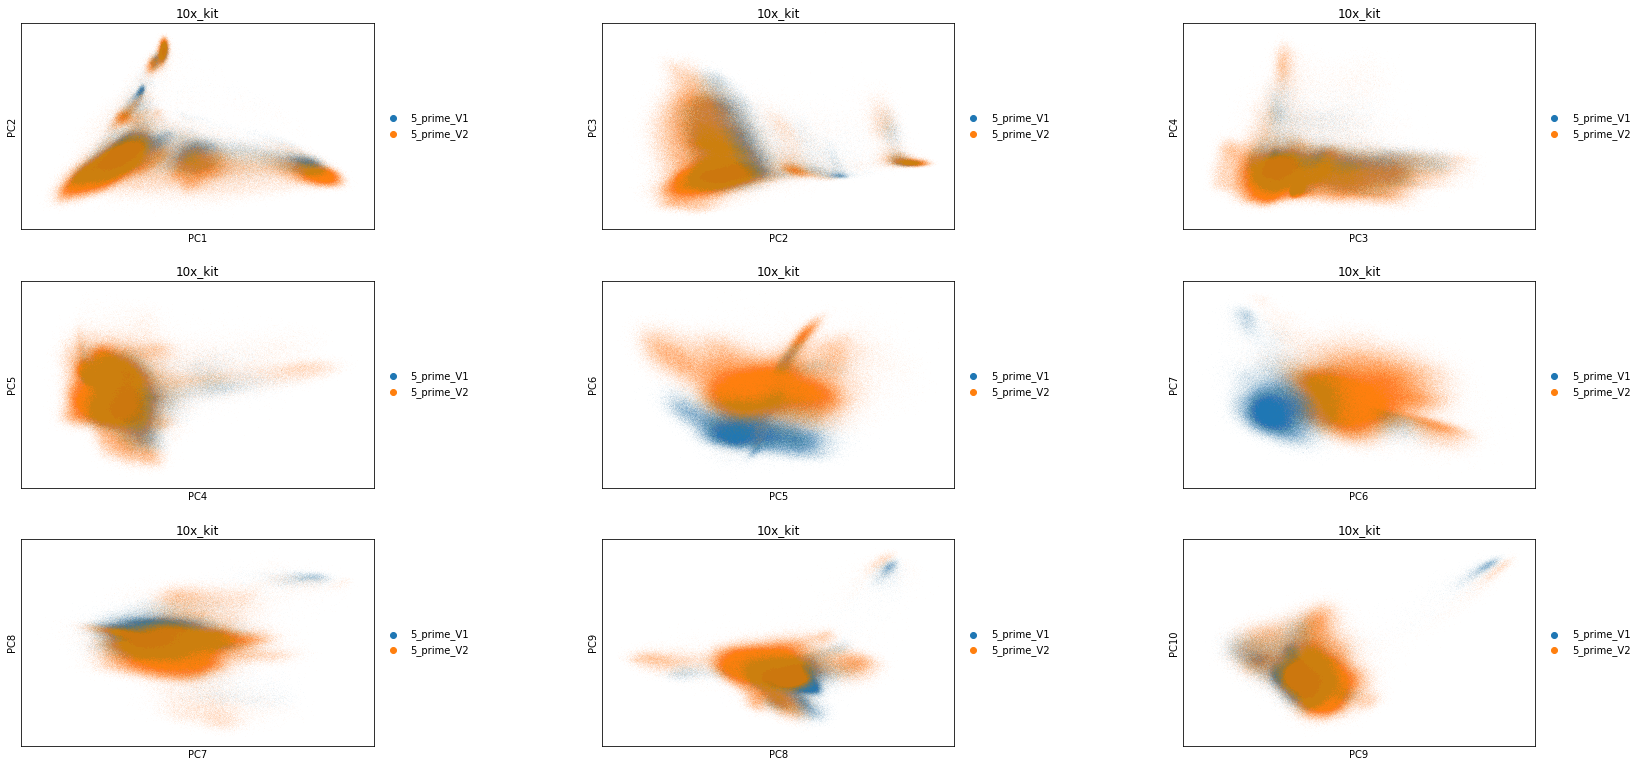

In [11]:
# plot PCs by Embryo section
sc.pl.pca(adata, color='10x_kit', components = ['1,2','2,3','3,4','4,5','5,6','6,7','7,8','8,9','9,10'], ncols=3, wspace=0.5, save='Principal_components_colored_by_10x_kit.pdf')

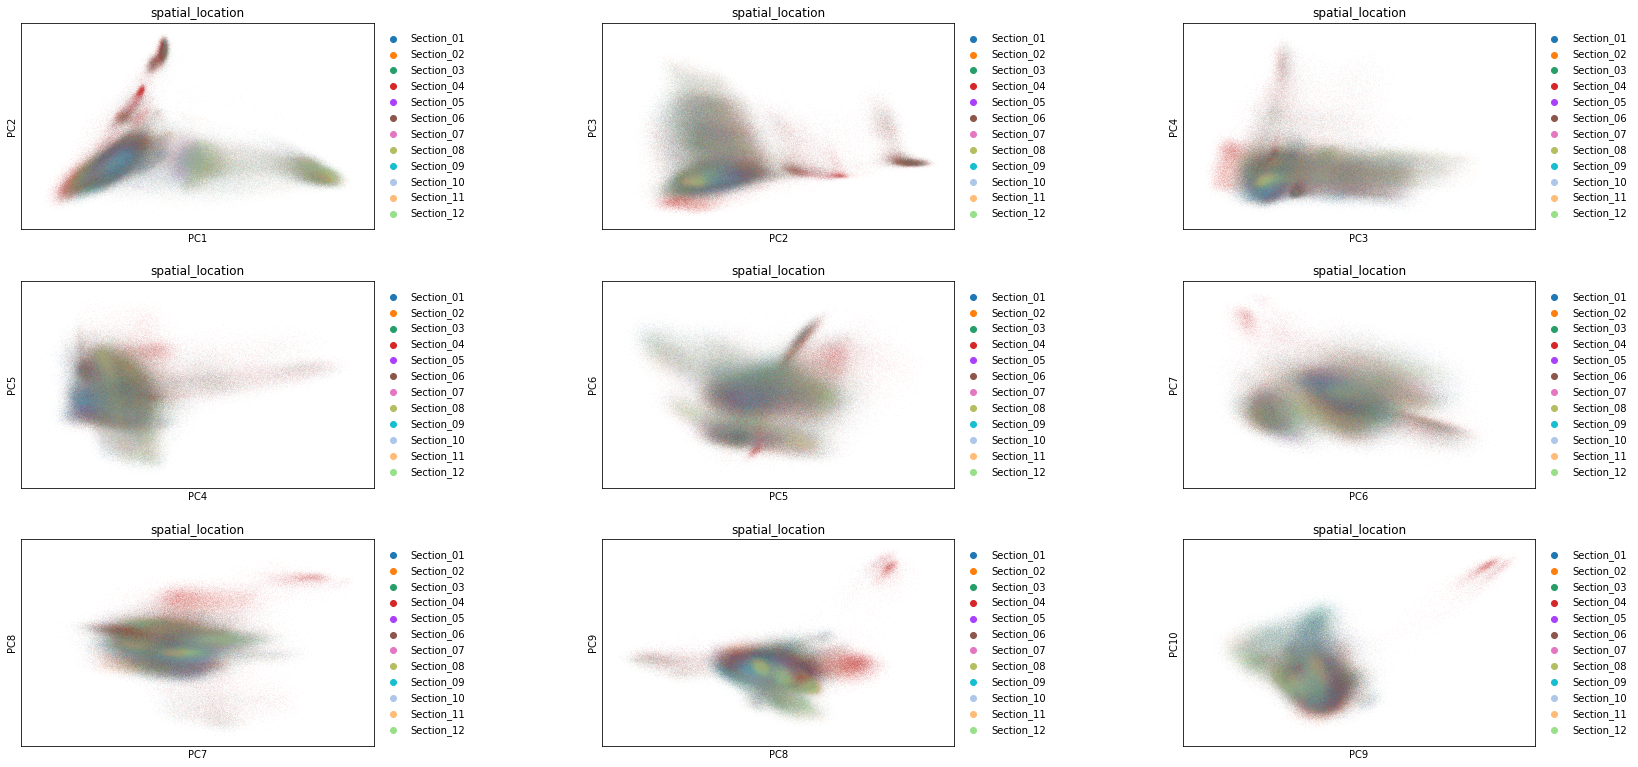

In [12]:
# plot PCs by anatomical section
sc.pl.pca(adata, color='spatial_location', components = ['1,2','2,3','3,4','4,5','5,6','6,7','7,8','8,9','9,10'], ncols=3, wspace=0.5, save='Principal_components_colored_by_spatial_location.pdf')

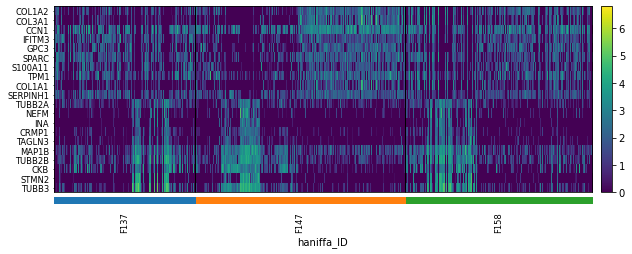

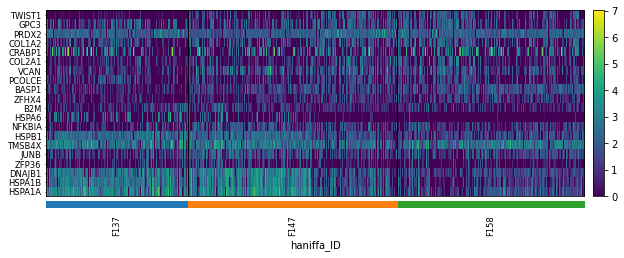

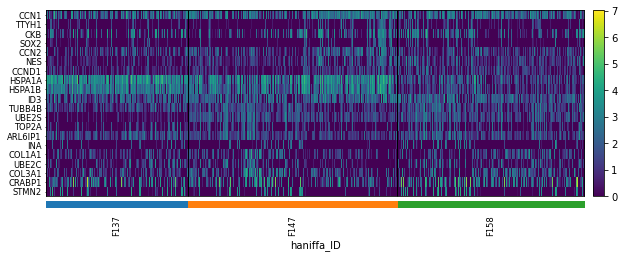

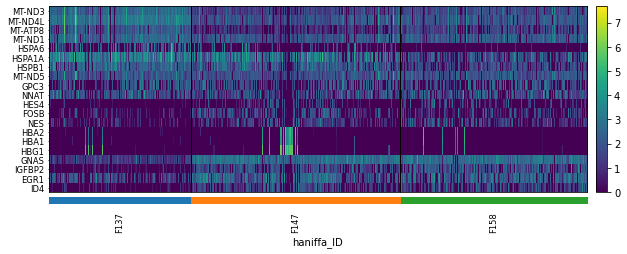

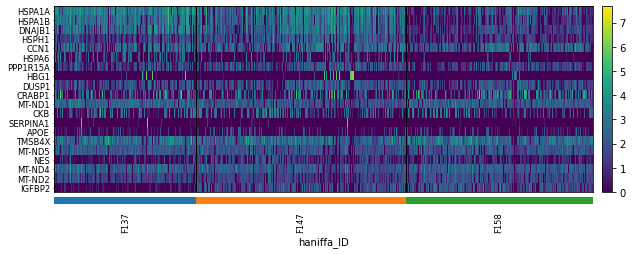

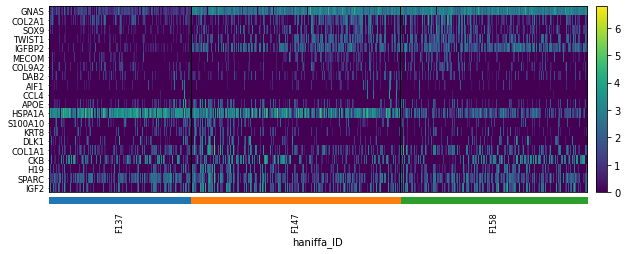

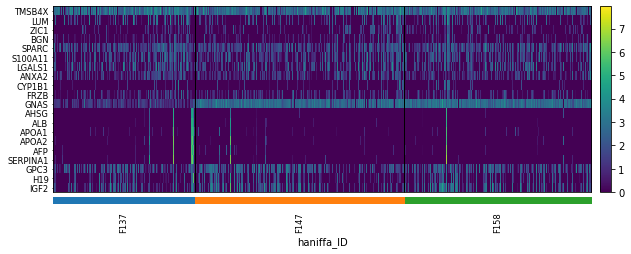

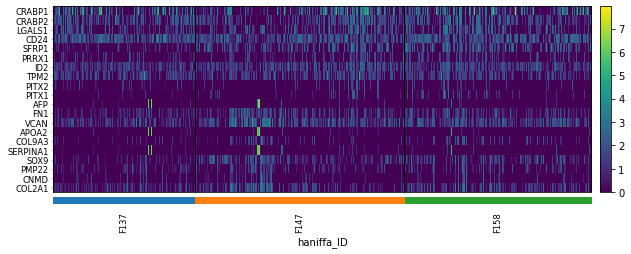

In [13]:
# Plot genes for top 10 PCs looking at both positive and negative axes by plotting their expression amongst cells ordered by their position along the pc

# adata.obsm["X_pca"] is the embeddings
# adata.uns["pca"] is pc variance
# adata.varm['PCs'] is the loadings

genes = adata.var['gene_ids']

for pc in [1,2,3,4,5,6,7,8,9,10]:
    g = adata.varm['PCs'][:,pc-1]
    o = np.argsort(g)
    sel = np.concatenate((o[:10],o[-10:])).tolist()
    emb = adata.obsm['X_pca'][:,pc-1]
    # order by position on that pc
    tempdata = adata[np.argsort(emb),]
    var_to_plot = genes[sel].index.tolist()
    sc.pl.heatmap(tempdata, var_names = var_to_plot, groupby='haniffa_ID', swap_axes = True, use_raw=False)

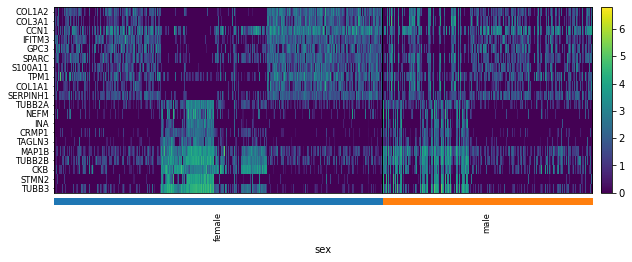

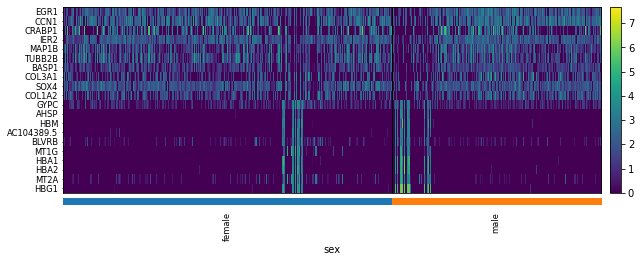

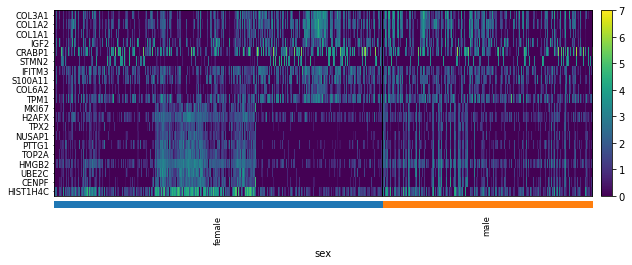

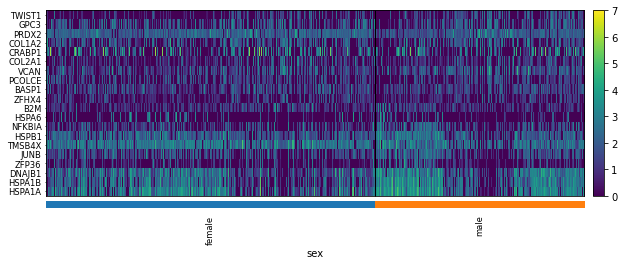

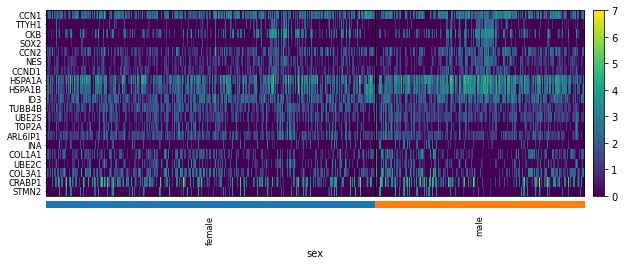

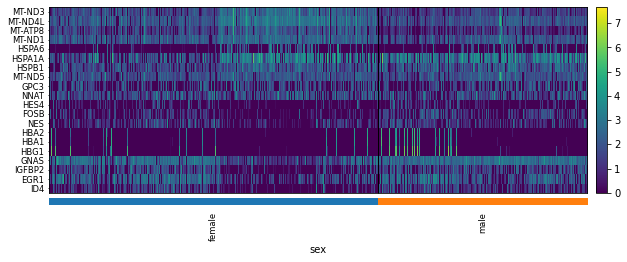

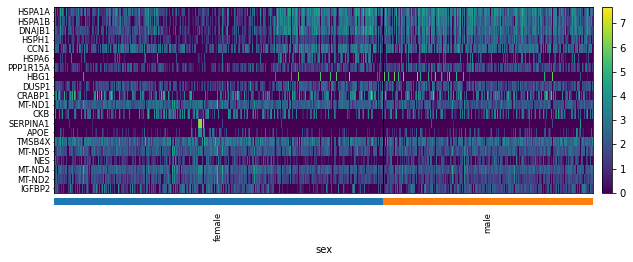

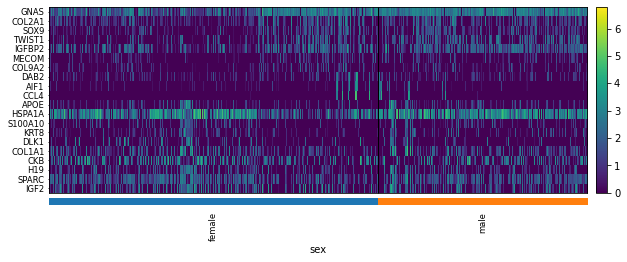

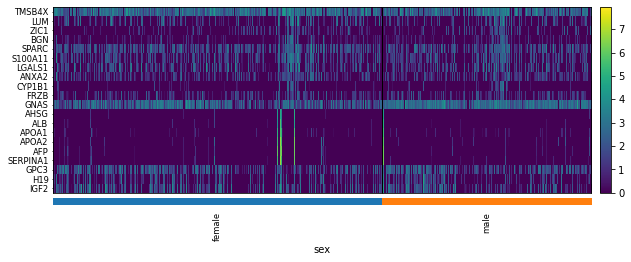

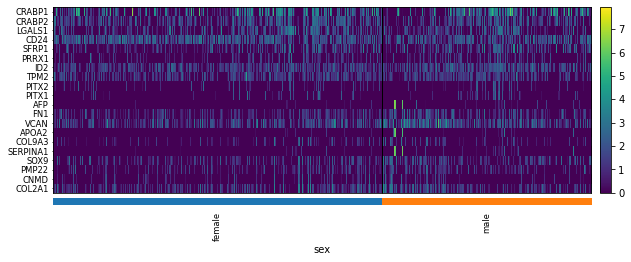

In [14]:
# Plot genes for top 10 PCs looking at both positive and negative axes by plotting their expression amongst cells ordered by their position along the pc
for pc in [1,2,3,4,5,6,7,8,9,10]:
    g = adata.varm['PCs'][:,pc-1]
    o = np.argsort(g)
    sel = np.concatenate((o[:10],o[-10:])).tolist()
    emb = adata.obsm['X_pca'][:,pc-1]
    # order by position on that pc
    tempdata = adata[np.argsort(emb),]
    var_to_plot = genes[sel].index.tolist()
    sc.pl.heatmap(tempdata, var_names = var_to_plot, groupby='sex', swap_axes = True, use_raw=False)

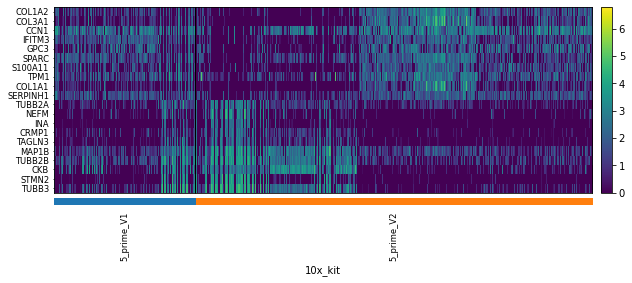

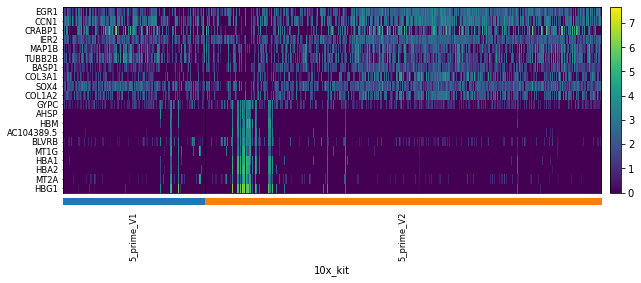

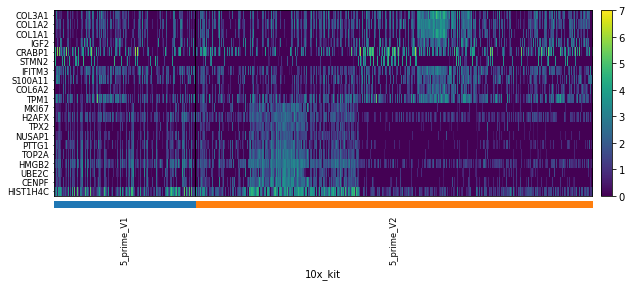

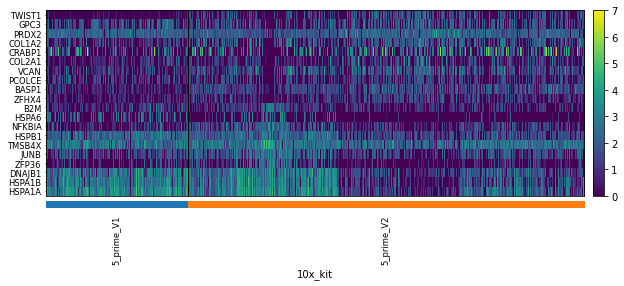

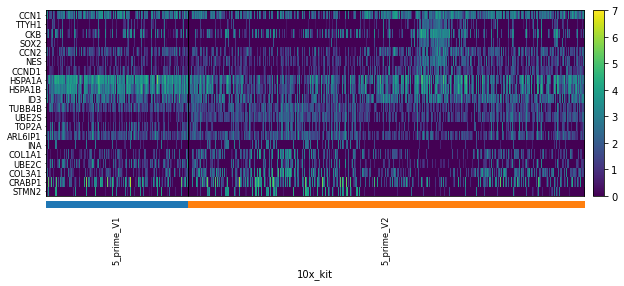

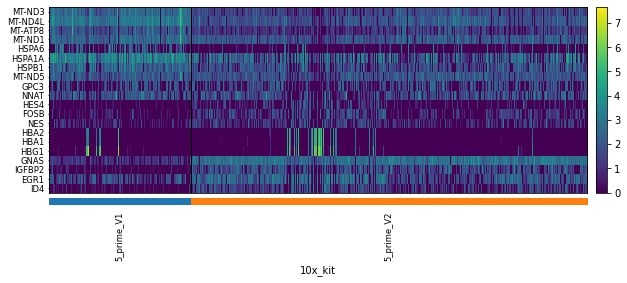

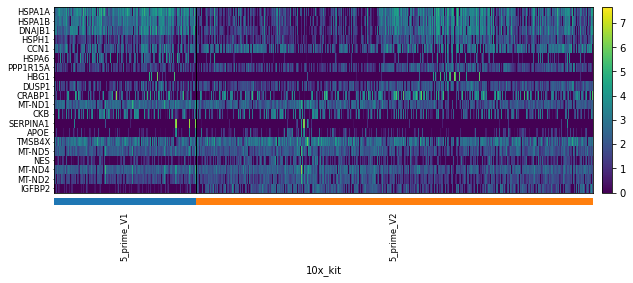

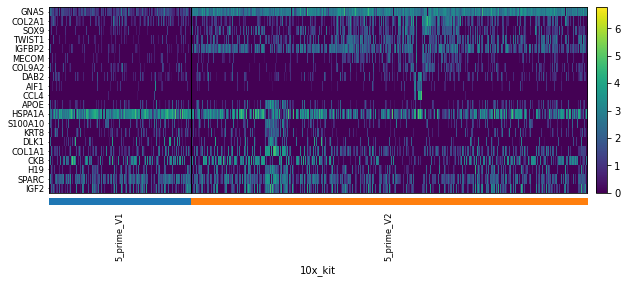

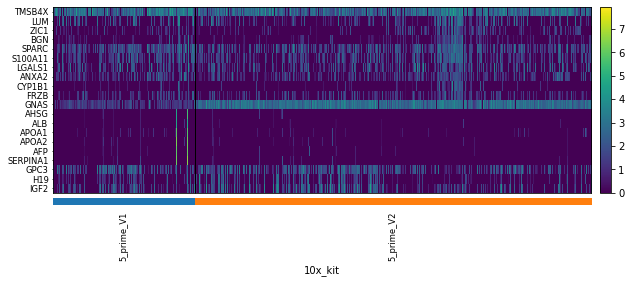

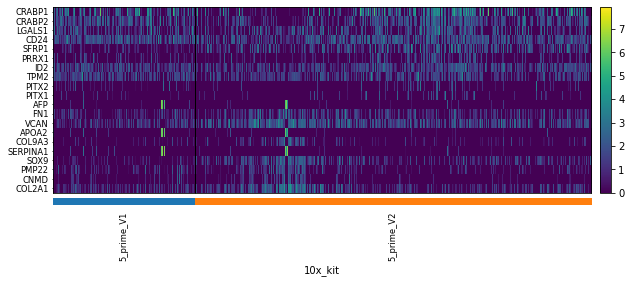

In [15]:
# Plot genes for top 10 PCs looking at both positive and negative axes by plotting their expression amongst cells ordered by their position along the pc
for pc in [1,2,3,4,5,6,7,8,9,10]:
    g = adata.varm['PCs'][:,pc-1]
    o = np.argsort(g)
    sel = np.concatenate((o[:10],o[-10:])).tolist()
    emb = adata.obsm['X_pca'][:,pc-1]
    # order by position on that pc
    tempdata = adata[np.argsort(emb),]
    var_to_plot = genes[sel].index.tolist()
    sc.pl.heatmap(tempdata, var_names = var_to_plot, groupby='10x_kit', swap_axes = True, use_raw=False)

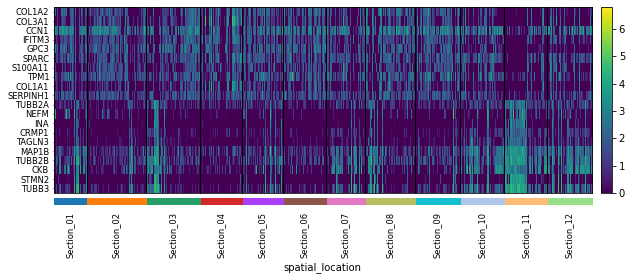

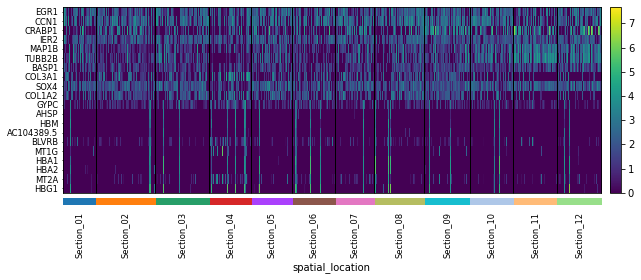

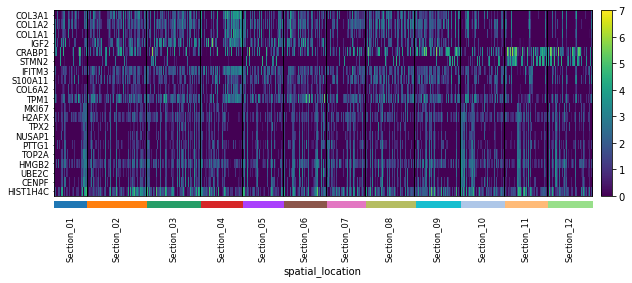

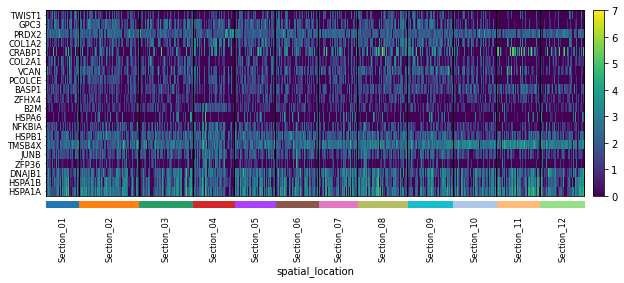

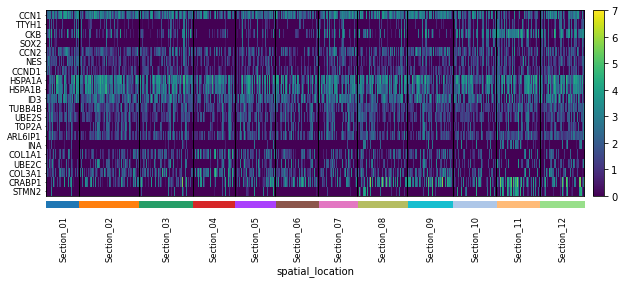

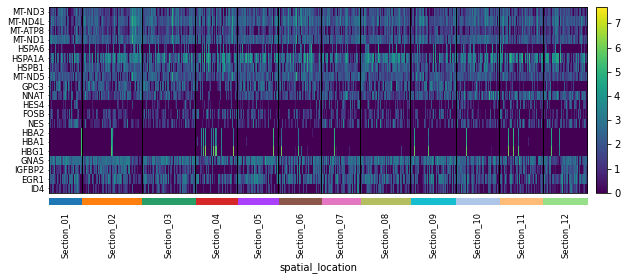

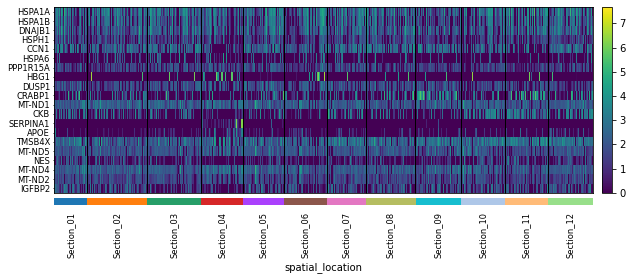

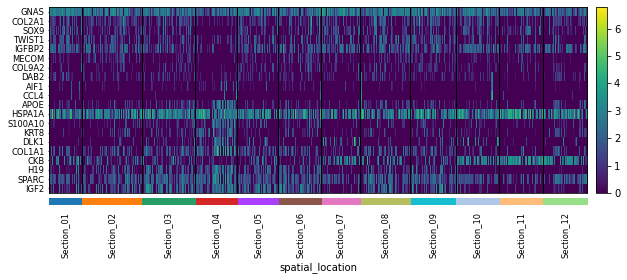

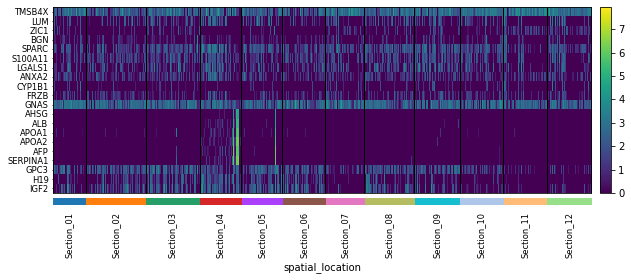

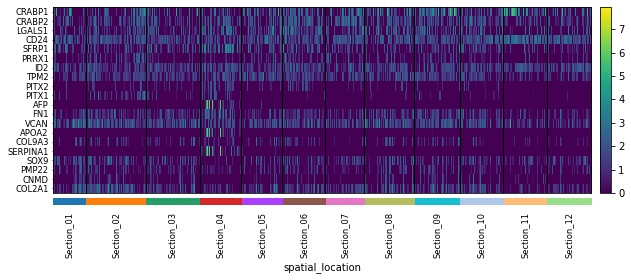

In [16]:
# Plot genes for top 10 PCs looking at both positive and negative axes by plotting their expression amongst cells ordered by their position along the pc
for pc in [1,2,3,4,5,6,7,8,9,10]:
    g = adata.varm['PCs'][:,pc-1]
    o = np.argsort(g)
    sel = np.concatenate((o[:10],o[-10:])).tolist()
    emb = adata.obsm['X_pca'][:,pc-1]
    # order by position on that pc
    tempdata = adata[np.argsort(emb),]
    var_to_plot = genes[sel].index.tolist()
    sc.pl.heatmap(tempdata, var_names = var_to_plot, groupby='spatial_location', swap_axes = True, use_raw=False)

computing neighbors
    using 'X_pca' with n_pcs = 75
    finished (0:03:26)
computing UMAP
    finished (0:33:58)


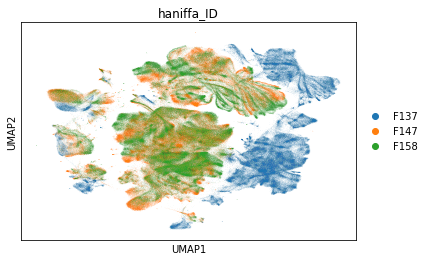

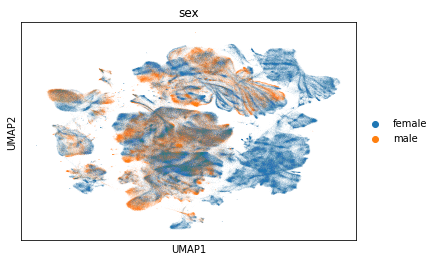

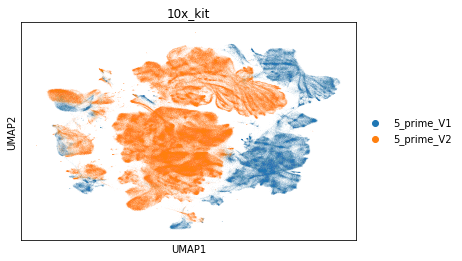

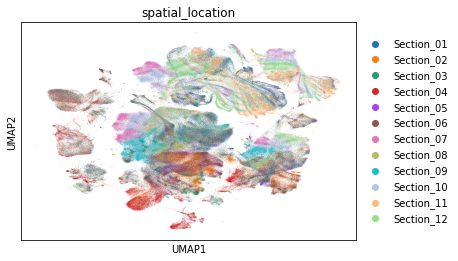

In [17]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=75) # neighbours identified from scree plot, default number of neighbours to begin with
sc.tl.umap(adata, random_state=umap_seed)
sc.pl.umap(adata, color='haniffa_ID', save='Combined_umap_non_batch_corrected_color_Embryos_' + date + '.pdf')
sc.pl.umap(adata, color='sex', save='Combined_umap_non_batch_corrected_color_sex_' + date + '.pdf')
sc.pl.umap(adata, color='10x_kit', save='Combined_umap_non_batch_corrected_color_10x_kit_' + date + '.pdf')
sc.pl.umap(adata, color='spatial_location', save='Combined_umap_non_batch_corrected_color_spatial_location_' + date + '.pdf')

# Conclusion:

- Embryo 2 and 3 naturally integrate with one another with some regions sitting side by side instead over one another: this may be due to male female differences 
- Embryo 1 clearly sits out compared to embryos 2 and 3 with the most likely cause being due to chemistry versioning 
- There visually looks to be a good mix and separation across sections indiciating that some celltypes are natrually merging across sections while some section specific cell types are sitting separately e.g. liver hepatocytes are know to sit separately from other celltypes which are located in Section_04 (marker expression of liver hepatocyte markers confirmed below)

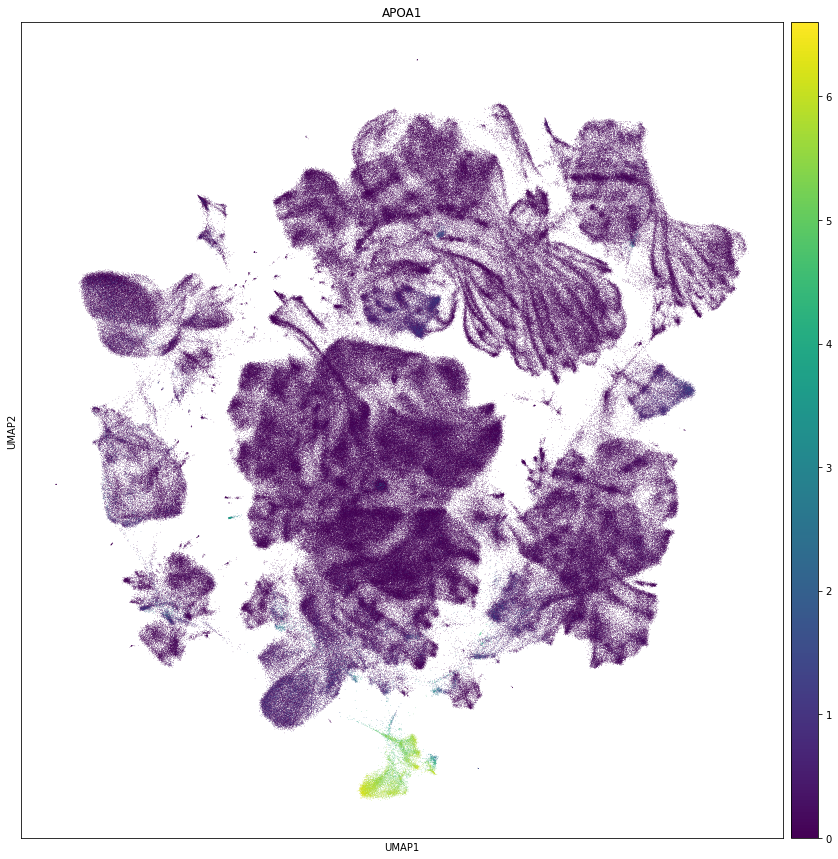

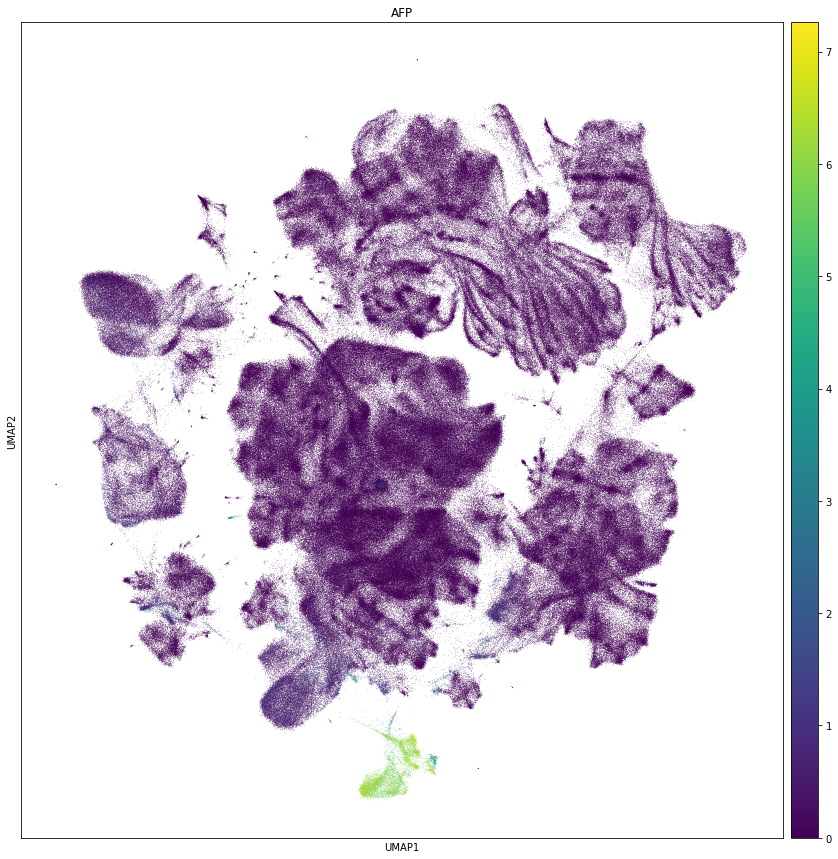

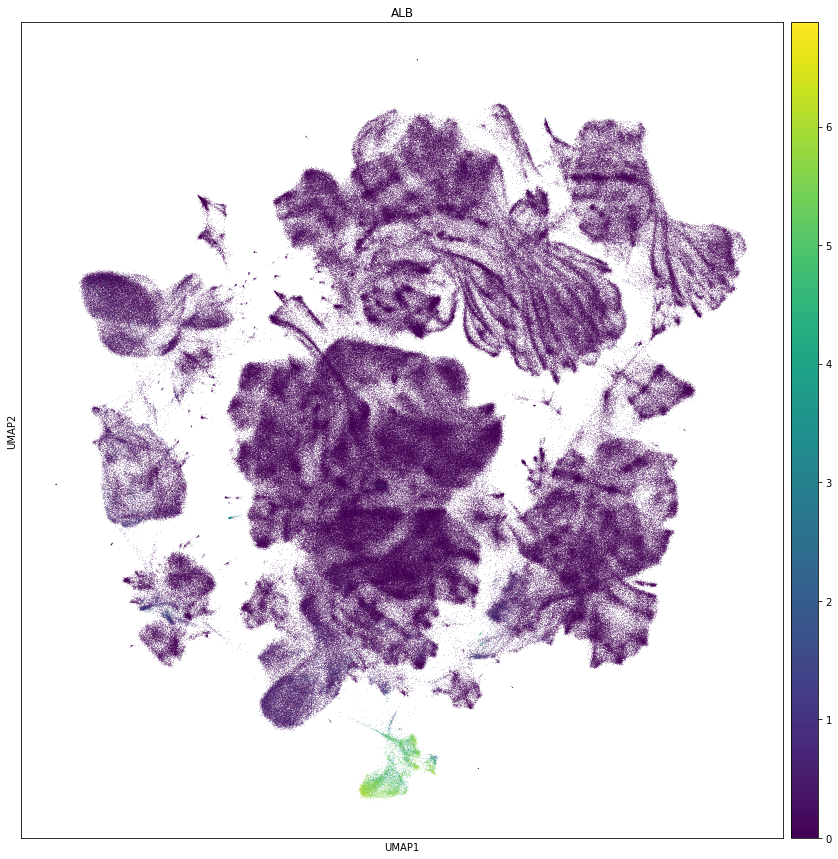

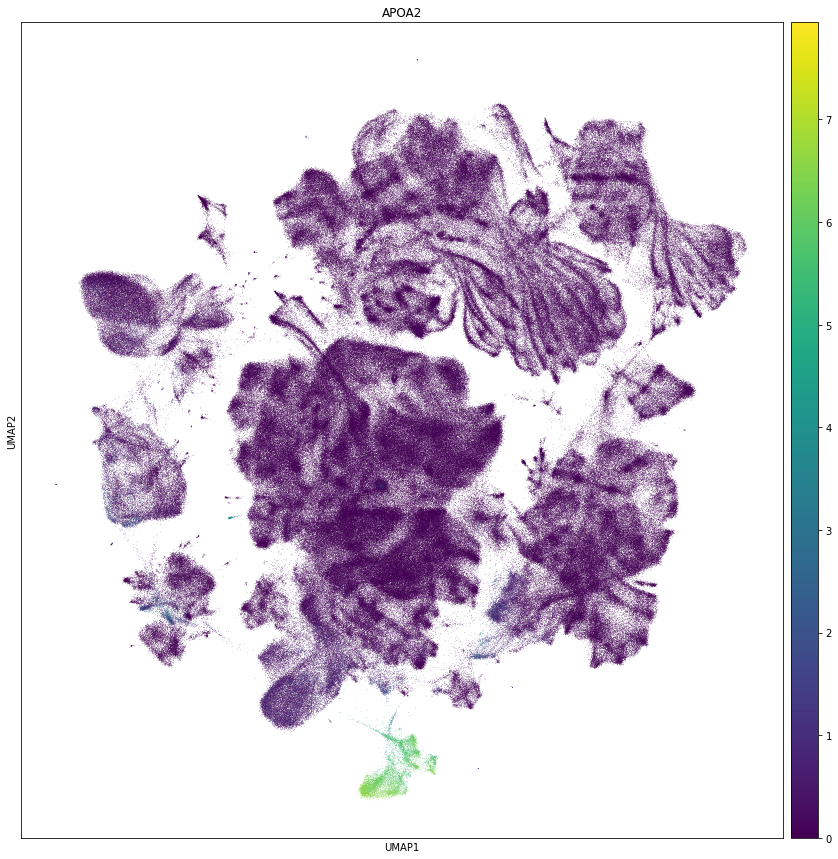

In [18]:
# Plot known liver hepatocyte markers on umap

genes = ['APOA1','AFP','ALB','APOA2']

for gene in genes:
    fig, ax = plt.subplots(figsize=(15, 15))
    sc.pl.umap(adata, color=gene, ax=ax, s=1)

# Save processed data with non batch corrected umap embedding

In [19]:
adata.write_h5ad(Objects_out_path + 'Combined_n_3_processed_log_norm_non_batch_corrected_' + date + '.h5ad')

***
### Dependencies
Here are some information about resources and import package versions used within this script

In [1]:
%load_ext watermark
%watermark -v -m -p numpy,pandas,scanpy,anndata

Python implementation: CPython
Python version       : 3.9.4
IPython version      : 7.24.1

numpy  : 1.20.3
pandas : 1.2.4
scanpy : 1.7.2
anndata: 0.7.6

Compiler    : GCC 9.3.0
OS          : Linux
Release     : 4.15.0-112-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 26
Architecture: 64bit

